In [6]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('week-03-hidden-pairs')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/week-03-hidden-pairs


In [7]:
!pip install cleanlab

In [8]:
import pandas as pd
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path
from tqdm.auto import tqdm
import time
import cleanlab
import json
from datetime import datetime

import joblib


In [9]:
def set_seed(seed=42):
    """Фиксирует seed для random, NumPy и PyTorch, включая CUDA."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.use_deterministic_algorithms(True, warn_only=True)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f'setted seed for {seed}')

In [10]:
SEED = 42
set_seed(SEED)

LOCAL = False

LOG_DIR = Path('./logs') if LOCAL else Path('/kaggle/working/logs')


setted seed for 42


In [11]:
DATA_DIR = Path('./data') if LOCAL else Path('/kaggle/input/competitions/week-03-hidden-pairs')

train_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'train.csv')
val_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'validation.csv')
test_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission: pd.DataFrame = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
print("sample submission:", sample_submission.shape)

train: (2520, 514)
val: (560, 514)
test: (1116, 513)
sample submission: (1116, 2)


In [12]:
assert train_df.isna().sum().sum() == 0, "train_df contains NaN values"
assert val_df.isna().sum().sum() == 0, "val_df contains NaN values"
assert test_df.isna().sum().sum() == 0, "test_df contains NaN values"

assert train_df['row_id'].is_unique, "train_df contains duplicate ids"
assert val_df['row_id'].is_unique, "val_df contains duplicate ids"
assert test_df['row_id'].is_unique, "test_df contains duplicate ids"

In [13]:
feature_columns: list[str] = [
    col for col in train_df.columns if col not in ['row_id', 'target']
]

X_train: pd.DataFrame = train_df[feature_columns]
y_train: pd.Series = train_df['target']

X_val: pd.DataFrame = val_df[feature_columns]
y_val: pd.Series = val_df['target']

X_test: pd.DataFrame = test_df[feature_columns]

print('# of features:', len(feature_columns))
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_val shape:', X_val.shape)
print('y_val shape:', y_val.shape)
print('X_test shape:', X_test.shape)

# of features: 512
X_train shape: (2520, 512)
y_train shape: (2520,)
X_val shape: (560, 512)
y_val shape: (560,)
X_test shape: (1116, 512)


In [14]:
def _extract_auc_history(model, X_train, y_train, X_val, y_val):
    """Возвращает списки train/val ROC AUC по итерациям бустинга.

    Для дерева и случайного леса возвращает два пустых списка.
    """
    if isinstance(model, CatBoostClassifier):
        history = model.get_evals_result()
        # Два eval_set при обучении: сначала train, затем validation.
        return history['validation_0']['AUC'], history['validation_1']['AUC']

    if isinstance(model, LGBMClassifier):
        history = model.evals_result_
        return history['train']['auc'], history['val']['auc']

    if isinstance(model, GradientBoostingClassifier):
        train_scores = [
            roc_auc_score(y_train, probs[:, 1])
            for probs in model.staged_predict_proba(X_train)
        ]
        val_scores = [
            roc_auc_score(y_val, probs[:, 1])
            for probs in model.staged_predict_proba(X_val)
        ]
        return train_scores, val_scores

    return [], []


def _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=False):
    """Обучает копию модели и возвращает вероятности, AUC, время fit и кривые.

    Validation используется для оценки; CatBoost сохраняет все итерации.
    use_cleanlab=True включает поиск ошибок разметки и обучение через CleanLearning.
    Train AUC считается на исходном train. Время fit включает работу CleanLearning,
    но не включает предсказания и вычисление истории AUC.
    """
    started_at = datetime.now().astimezone().isoformat()
    fitted_model = clone(model)
    print('  Обучение...', flush=True)
    start_time = time.perf_counter()

    fit_kwargs = {}
    if isinstance(fitted_model, CatBoostClassifier):
        fitted_model.set_params(eval_metric='AUC:hints=skip_train~false', verbose=False)
        fit_kwargs = {
            'eval_set': [(X_train, y_train), (X_val, y_val)],
            'use_best_model': False,
            'verbose': False,
        }
    elif isinstance(fitted_model, LGBMClassifier):
        fit_kwargs = {
            'eval_set': [(X_train, y_train), (X_val, y_val)],
            'eval_names': ['train', 'val'],
            'eval_metric': 'auc',
        }

    if use_cleanlab:
        print('  CleanLearning: ищу ошибки разметки на train и обучаю модель...', flush=True)
        clean_model = cleanlab.classification.CleanLearning(
            clf=fitted_model, seed=SEED, verbose=True,
            find_label_issues_kwargs={'n_jobs': 1},
        )
        # Validation передаётся только финальному fit, не внутренним CV-моделям.
        clean_model.fit(X_train, y_train, clf_final_kwargs=fit_kwargs)
        fitted_model = clean_model.clf
        n_issues = int(clean_model.get_label_issues()['is_label_issue'].sum())
        print(f'  CleanLearning: исключено {n_issues} из {len(y_train)} строк.', flush=True)
    else:
        fitted_model.fit(X_train, y_train, **fit_kwargs)

    fit_time = time.perf_counter() - start_time
    print(f'  Fit завершён за {fit_time:.1f} с. Считаю предсказания и AUC...', flush=True)
    train_probs = fitted_model.predict_proba(X_train)[:, 1]
    val_probs = fitted_model.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    print(f'  Train AUC: {train_auc:.5f} | Val AUC: {val_auc:.5f}', flush=True)
    print('  Извлекаю историю AUC по итерациям...', flush=True)
    train_history, val_history = _extract_auc_history(
        fitted_model, X_train, y_train, X_val, y_val,
    )

    print('  Модель готова.', flush=True)
    return {
        'model': fitted_model,
        'started_at': started_at,
        'params': fitted_model.get_params(deep=False),
        'val_probs': val_probs,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'fit_time': fit_time,
        'train_history': train_history,
        'val_history': val_history,
    }


def _plot_learning_curves(histories, ncols=2):
    """Рисует train/val ROC AUC по итерациям для моделей с историей обучения."""
    histories = {name: result for name, result in histories.items() if result['val_history']}
    if not histories:
        return

    sns.set_theme(style='darkgrid')
    nrows = (len(histories) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False,
    )
    axes = axes.ravel()

    for ax, (name, result) in zip(axes, histories.items()):
        for key, label in [('train_history', 'Train AUC'), ('val_history', 'Val AUC')]:
            scores = result[key]
            ax.plot(range(1, len(scores) + 1), scores, label=label)
        ax.set(title=name, xlabel='Iteration', ylabel='ROC AUC')
        ax.legend()

    # Удаление неиспользуемых ячеек сетки (если количество моделей нечетное)
    for ax in axes[len(histories):]:
        fig.delaxes(ax)

    fig.tight_layout()
    plt.show()


def _save_trained_model(model, log_path, model_index, use_cleanlab):
    """Сохраняет обученный классификатор и возвращает путь относительно LOG_DIR.

    После joblib.load() модель готова к predict_proba() без повторного обучения.
    Для CleanLearning сохраняется его финальный обученный классификатор.
    """
    model_dir = log_path.with_suffix('')
    model_dir.mkdir(parents=True, exist_ok=True)
    variant = 'cleanlab' if use_cleanlab else 'base'
    model_path = model_dir / f'{model_index:02d}_{variant}.joblib'
    joblib.dump(model, model_path, compress=3)
    print(f'  Обученная модель сохранена: {model_path}', flush=True)
    return str(model_path.relative_to(log_path.parent))


def _save_pipeline_log(log_path, started_at, metrics_list):
    """Сохраняет время запуска, параметры и метрики уже обученных моделей в JSON."""
    log_data = {
        'run_started_at': started_at.isoformat(),
        'updated_at': datetime.now().astimezone().isoformat(),
        'results': json.loads(pd.DataFrame(metrics_list).to_json(orient='records', double_precision=15)),
    }
    log_path.write_text(json.dumps(log_data, ensure_ascii=False, indent=2), encoding='utf-8')


def run_model_pipeline(
    models_dict, X_train, y_train, X_val, y_val, plot_curves=True, use_cleanlab=False,
):
    """Обучает модели и возвращает вероятности на val и таблицу AUC/времени.

    Строки вероятностей соответствуют X_val; метрики отсортированы по Val AUC.
    use_cleanlab=True запускает каждую модель дважды: без очистки, затем с ней.
    Версия с очисткой получает суффикс " + Cleanlab" в таблицах и графиках.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"pipeline_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Пайплайн: {len(models_dict)} моделей | train={X_train.shape}, val={X_val.shape}', flush=True)
    for i, (name, model) in enumerate(models_dict.items(), start=1):
        print(f'\n[{i}/{len(models_dict)}] {name}', flush=True)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)
            model_file = _save_trained_model(
                result.pop('model'), log_path, i, cleanlab_enabled,
            )
            val_predictions[run_name] = result['val_probs']
            histories[run_name] = result
            metrics_list.append({
                'Model': run_name,
                'Started At': result['started_at'],
                'Params': result['params'],
                'Model File': model_file,
                'Cleanlab': cleanlab_enabled,
                'Train AUC': result['train_auc'],
                'Val AUC': result['val_auc'],
                'Fit Time (s)': round(result['fit_time'], 3),
            })
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df


def run_model_pipeline_search(
    models_dict, param_grids, X_train, y_train, X_val, y_val,
    n_iter=10, cv=5, scoring='roc_auc', verbose=10, n_jobs=-1, plot_curves=True,
    use_cleanlab=False,
):
    """Подбирает параметры на train для моделей, перечисленных в param_grids.

    Параметры подбираются один раз без CleanLearning. При use_cleanlab=True
    лучшая конфигурация обучается без очистки, затем с ней. CV Score/STD в обеих
    строках относятся к одному поиску без очистки.
    Возвращает вероятности и метрики: CV Score/STD относятся к scoring,
    Train/Val AUC — к финальной модели, Fit Time — к её обучению без поиска.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"search_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Поиск: {len(param_grids)} моделей | метрика={scoring}', flush=True)
    if use_cleanlab:
        print('CleanLearning включён после поиска. CV Score — без очистки.', flush=True)
    for i, (name, param_grid) in enumerate(param_grids.items(), start=1):
        print(f'\n[{i}/{len(param_grids)}] {name}: подбор параметров...', flush=True)
        model = models_dict[name]
        search = RandomizedSearchCV(
            model, param_distributions=param_grid, n_iter=n_iter,
            cv=cv, scoring=scoring, random_state=SEED,
            verbose=verbose, n_jobs=n_jobs, refit=False,
        )
        search_start = time.perf_counter()
        search.fit(X_train, y_train)
        print(
            f'  Поиск завершён за {time.perf_counter() - search_start:.1f} с. '
            f'Лучший CV {scoring}: {search.best_score_:.5f}',
            flush=True,
        )
        print(f'  Параметры: {search.best_params_}', flush=True)
        print('  Обучаю лучшую конфигурацию на всём train.', flush=True)
        best_model = clone(model).set_params(**search.best_params_)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(best_model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)

            model_file = _save_trained_model(
                result.pop('model'), log_path, i, cleanlab_enabled,
            )
            val_predictions[run_name] = result['val_probs']
            histories[run_name] = result
            metrics_list.append({
                'Model': run_name,
                'Started At': result['started_at'],
                'Params': result['params'],
                'Model File': model_file,
                'Cleanlab': cleanlab_enabled,
                'Best Params': search.best_params_,
                'CV Score': search.best_score_,
                'CV STD': search.cv_results_['std_test_score'][search.best_index_],
                'Train AUC': result['train_auc'],
                'Val AUC': result['val_auc'],
                'Fit Time (s)': round(result['fit_time'], 3),
            })
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df


In [15]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=SEED,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=5,
        max_features=0.5,
        random_state=SEED,
        n_jobs=-1,
    ),
    'Random Forest regularized': RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1,
    ),
    'GBDT 3': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=SEED,
    ),
    'GBDT 5': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=SEED,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=30,
        colsample_bytree=0.8,
        subsample=0.8,
        subsample_freq=1,
        reg_lambda=5,
        metric='auc',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    ),
    'CatBoost': CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=5,
        l2_leaf_reg=5,
        eval_metric='AUC:hints=skip_train~false',
        random_seed=SEED,
        verbose=False,
    ),
}

Лог запуска: /kaggle/working/logs/pipeline_2026-09-19_20-26-50_999768.json
Пайплайн: 7 моделей | train=(2520, 512), val=(560, 512)

[1/7] Decision Tree
  Вариант: Decision Tree
  Обучение...
  Fit завершён за 1.1 с. Считаю предсказания и AUC...
  Train AUC: 0.89054 | Val AUC: 0.78791
  Извлекаю историю AUC по итерациям...
  Модель готова.
  Обученная модель сохранена: /kaggle/working/logs/pipeline_2026-09-19_20-26-50_999768/01_base.joblib
  Результат сохранён: pipeline_2026-09-19_20-26-50_999768.json

[2/7] Random Forest
  Вариант: Random Forest
  Обучение...
  Fit завершён за 84.0 с. Считаю предсказания и AUC...
  Train AUC: 0.99986 | Val AUC: 0.90362
  Извлекаю историю AUC по итерациям...
  Модель готова.
  Обученная модель сохранена: /kaggle/working/logs/pipeline_2026-09-19_20-26-50_999768/02_base.joblib
  Результат сохранён: pipeline_2026-09-19_20-26-50_999768.json

[3/7] Random Forest regularized
  Вариант: Random Forest regularized
  Обучение...
  Fit завершён за 6.2 с. Считаю пр

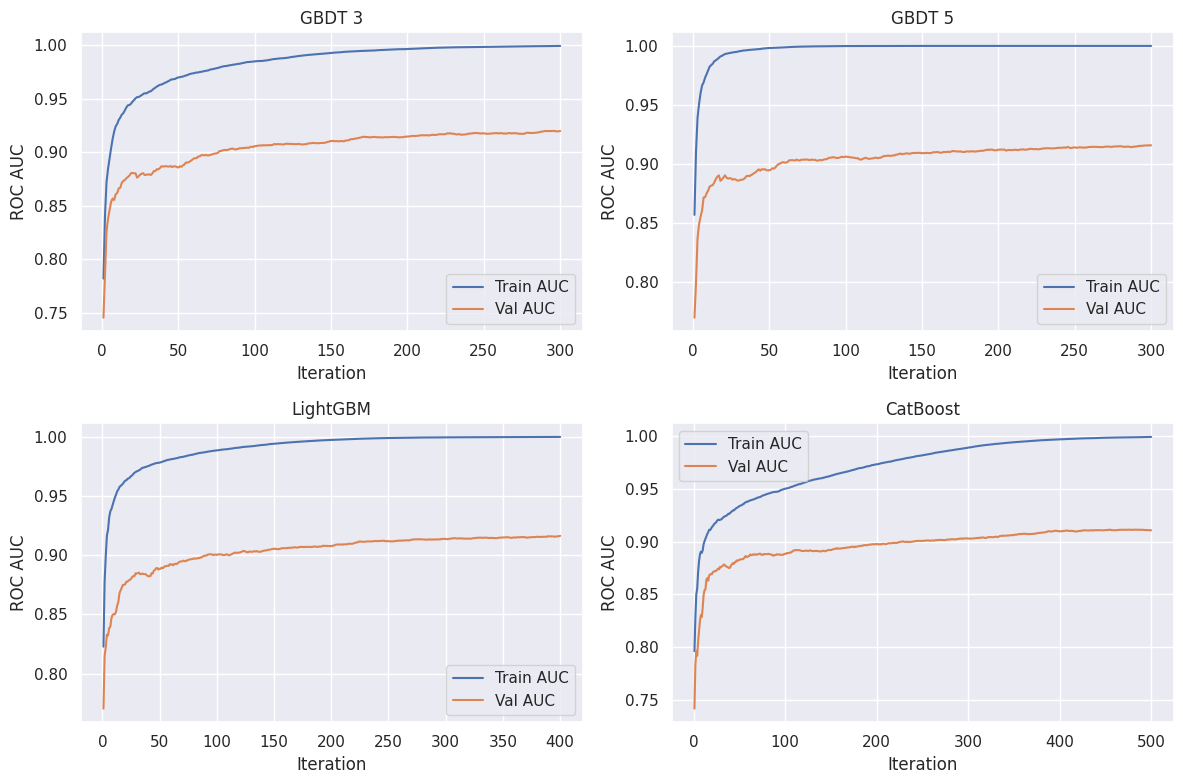

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [17]:
preds_df, metrics_df = run_model_pipeline(
    models, X_train, y_train, X_val, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [18]:
metrics_df

,Model,Started At,Params,Model File,Cleanlab,Train AUC,Val AUC,Fit Time (s)
0,GBDT 3,2026-09-19T20:28:23.367387+00:00,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",pipeline_2026-09-19_20-26-50_999768/04_base.jo...,False,0.999281,0.919898,163.697
1,LightGBM,2026-09-19T20:35:30.949831+00:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-19_20-26-50_999768/06_base.jo...,False,0.999856,0.916314,3.773
2,GBDT 5,2026-09-19T20:31:08.206975+00:00,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",pipeline_2026-09-19_20-26-50_999768/05_base.jo...,False,1.000000,0.915906,261.516
3,CatBoost,2026-09-19T20:35:34.821385+00:00,"{'iterations': 500, 'learning_rate': 0.03, 'de...",pipeline_2026-09-19_20-26-50_999768/07_base.jo...,False,0.999451,0.910727,19.636
4,Random Forest,2026-09-19T20:26:52.090444+00:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-19_20-26-50_999768/02_base.jo...,False,0.999858,0.903622,83.984
5,Random Forest regularized,2026-09-19T20:28:16.642986+00:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-19_20-26-50_999768/03_base.jo...,False,0.995570,0.887666,6.180
6,Decision Tree,2026-09-19T20:26:51.003651+00:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-19_20-26-50_999768/01_base.jo...,False,0.890544,0.787908,1.064


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', 0.5],
    },
}

In [ ]:
# preds_df_search, metrics_df_search = run_model_pipeline_search(models, param_grids, X_train, y_train, X_val, y_val, n_iter=30, cv=cv, scoring='roc_auc', plot_curves=True, verbose=10, n_jobs=-1)

In [ ]:
preds_df_search

In [ ]:
metrics_df_search.to_clipboard(index=False)
metrics_df_search

In [ ]:
# run_model_pipeline определён выше, в ячейке с функциями.

In [ ]:
model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=SEED, n_jobs=-1)
cl = cleanlab.classification.CleanLearning(model, seed=SEED, verbose=True)
cl.fit(X_train, y_train)
model = clone(model)
model.fit(X_train, y_train)

# issues = cl.get_label_issues()
# print(issues['is_label_issue'].sum())
print("Val AUC (cleaned):", roc_auc_score(y_val, cl.predict_proba(X_val)[:, 1]))
print('Val AUC (model):', roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
print('model params:', model.get_params())

### Предсказания сохранённой модели

Укажи JSON и имя модели в следующей ячейке. Нужны JSON **и папка с `.joblib` рядом с ним**. Для запуска достаточно выполнить импорты, настройки и подготовку данных выше; обучение запускать не нужно.

In [28]:
# Укажи JSON запуска и точное имя модели из поля Model.
JSON_PATH = LOG_DIR / 'pipeline_2026-09-19_20-51-16_279271.json'
MODEL_NAME = 'LightGBM + Cleanlab'  # Например: 'Random Forest + Cleanlab'
SUBMISSION_PATH = Path('submission.csv')

run_log = json.loads(JSON_PATH.read_text(encoding='utf-8'))
model_info = next(row for row in run_log['results'] if row['Model'] == MODEL_NAME)
model_path = JSON_PATH.parent / model_info['Model File']

print(f'Загружаю {MODEL_NAME}: {model_path}', flush=True)
selected_model = joblib.load(model_path)

# Только предсказания: повторное обучение не запускается.
print(f'Предсказываю для {len(X_test)} строк...', flush=True)
test_probs = selected_model.predict_proba(X_test)[:, 1]
submission = sample_submission[['row_id']].merge(
    pd.DataFrame({'row_id': test_df['row_id'], 'target': test_probs}),
    on='row_id', how='left', sort=False,
)
submission.to_csv(SUBMISSION_PATH, index=False)
print(f'Сохранено: {SUBMISSION_PATH.resolve()} | {submission.shape}', flush=True)
submission.head()


Загружаю LightGBM + Cleanlab: /kaggle/working/logs/pipeline_2026-09-19_20-51-16_279271/01_cleanlab.joblib
Предсказываю для 1116 строк...
Сохранено: /kaggle/working/submission.csv | (1116, 2)


,row_id,target
0,row_46ad1afad8562239f79c,0.991379
1,row_b42ade9cd57b8d919acb,0.941982
2,row_c951cd5e197b6b4e8b83,0.207524
3,row_a54b3423760d599416ce,0.019273
4,row_a87c87cc47690e2a303f,0.997871


In [25]:
def save_submission(selected_model):
    print(f'Предсказываю для {len(X_test)} строк...', flush=True)
    test_probs = selected_model.predict_proba(X_test)[:, 1]
    submission = sample_submission[['row_id']].merge(
        pd.DataFrame({'row_id': test_df['row_id'], 'target': test_probs}),
        on='row_id', how='left', sort=False,
    )
    submission.to_csv(SUBMISSION_PATH, index=False)
    print(f'Сохранено: {SUBMISSION_PATH.resolve()} | {submission.shape}', flush=True)
    submission.head()

Лог запуска: /kaggle/working/logs/pipeline_2026-09-19_20-51-16_279271.json
Пайплайн: 1 моделей | train=(2520, 512), val=(560, 512)

[1/1] LightGBM
  Вариант: LightGBM
  Обучение...
  Fit завершён за 3.9 с. Считаю предсказания и AUC...
  Train AUC: 0.99986 | Val AUC: 0.91631
  Извлекаю историю AUC по итерациям...
  Модель готова.
  Обученная модель сохранена: /kaggle/working/logs/pipeline_2026-09-19_20-51-16_279271/01_base.joblib
  Результат сохранён: pipeline_2026-09-19_20-51-16_279271.json
  Вариант: LightGBM + Cleanlab
  Обучение...
  CleanLearning: ищу ошибки разметки на train и обучаю модель...
Computing out of sample predicted probabilities via 5-fold cross validation. May take a while ...
Using predicted probabilities to identify label issues ...
Identified 204 examples with label issues.
Pruning 204 examples with label issues ...
Remaining clean data has 2316 examples.
Assigning sample weights for final training based on estimated label quality.
Fitting final model on the clean 

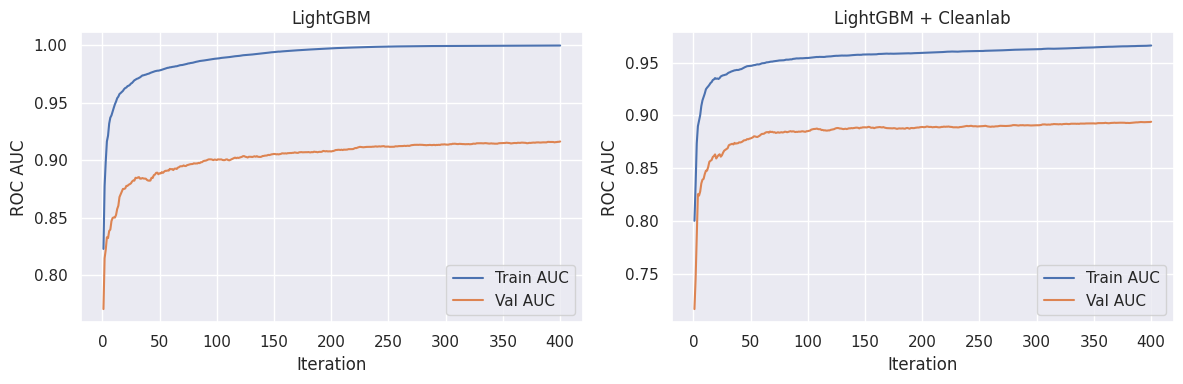

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [23]:
models_clean = {'LightGBM': models['LightGBM']}
preds_df, metrics_df = run_model_pipeline(
    models_clean, X_train, y_train, X_val, y_val,
    use_cleanlab=True,  # True — сравнить обычную модель и CleanLearning
)

In [27]:
metrics_df['Model']

0               LightGBM
1    LightGBM + Cleanlab
Name: Model, dtype: object

In [ ]:
save_submission()